# Simulations for consumer-resource model with externally supplied resources

This notebook contains simulations for consumer-resource model with externally supplied resources that generate the results in SI Sec. E. See SI Sec. C for model definition.

In [7]:
import numpy as np
import pandas as pd
import numbers
import copy
from scipy.stats import norm
from numpy.random import dirichlet
import cvxpy as cp
import matplotlib.pyplot as plt
import scipy as sp
from sklearn.linear_model import LinearRegression
from joblib import Parallel, delayed
import pickle
from tqdm import tqdm

## Sampling of community, parent, and mutant

In [256]:
# Model parameters

S = 50
M = 50
mu = 2
sigma = 0.4
K0 = 500
mu_m = 2
sigma_m = 0.2
l = 0
threshold = 10 ** -7

In [260]:
# Sampling function for general purpose, including externally supplied resources and cross-feeding

def BinaryRandomMatrix(a,b,p):
    """
    Construct binary random matrix.
    
    a, b = matrix dimensions
    
    p = probability that element equals 1 (otherwise 0)
    """
    r = np.random.rand(a,b)
    m = np.zeros((a,b))
    m[r<p] = 1.0
    
    return m

def MakeMatrices(assumptions):
    """
    Construct consumer matrix and metabolic matrix.
    
    assumptions = dictionary of metaparameters
        'sampling' = {'Gaussian','Binary','Gamma'} specifies choice of sampling algorithm
        'SA' = number of species in each family
        'MA' = number of resources of each type
        'Sgen' = number of generalist species
        'muc' = mean sum of consumption rates
        'sigc' = standard deviation for Gaussian sampling of consumer matrix
        'q' = family preference strength (from 0 to 1)
        'c0' = row sum of background consumption rates for Binary sampling
        'c1' = specific consumption rate for Binary sampling
        ##The following are irrelevant if you need c consumer matrix only)##
        'fs' = fraction of secretion flux into same resource type
        'fw' = fraction of secretion flux into waste resource type
        'sparsity' = effective sparsity of metabolic matrix (from 0 to 1)
        'wate_type' = index of resource type to designate as "waste"
    
    Returns:
    c = consumer matrix
    D = metabolic matrix
    """
    #PREPARE VARIABLES
    #Force number of species to be an array:
    if isinstance(assumptions['MA'],numbers.Number):
        assumptions['MA'] = [assumptions['MA']]
    if isinstance(assumptions['SA'],numbers.Number):
        assumptions['SA'] = [assumptions['SA']]
    #Force numbers of species to be integers:
    assumptions['MA'] = np.asarray(assumptions['MA'],dtype=int)
    assumptions['SA'] = np.asarray(assumptions['SA'],dtype=int)
    assumptions['Sgen'] = int(assumptions['Sgen'])
    #Default waste type is last type in list:
    if 'waste_type' not in assumptions.keys():
        assumptions['waste_type']=len(assumptions['MA'])-1

    #Extract total numbers of resources, consumers, resource types, and consumer families:
    M = np.sum(assumptions['MA'])
    T = len(assumptions['MA'])
    S = np.sum(assumptions['SA'])+assumptions['Sgen']
    F = len(assumptions['SA'])
    M_waste = assumptions['MA'][assumptions['waste_type']]
    #Construct lists of names of resources, consumers, resource types, and consumer families:
    resource_names = ['R'+str(k) for k in range(M)]
    type_names = ['T'+str(k) for k in range(T)]
    family_names = ['F'+str(k) for k in range(F)]
    consumer_names = ['S'+str(k) for k in range(S)]
    waste_name = type_names[assumptions['waste_type']]
    resource_index = [[type_names[m] for m in range(T) for k in range(assumptions['MA'][m])],
                      resource_names]
    consumer_index = [[family_names[m] for m in range(F) for k in range(assumptions['SA'][m])]
                      +['GEN' for k in range(assumptions['Sgen'])],consumer_names]
    
    #PERFORM GAUSSIAN SAMPLING
    if assumptions['sampling'] == 'Gaussian':
        #Initialize dataframe:
        c = pd.DataFrame(np.zeros((S,M)),columns=resource_index,index=consumer_index)
        #Add Gaussian-sampled values, biasing consumption of each family towards its preferred resource:
        for k in range(F):
            for j in range(T):
                if k==j:
                    c_mean = (assumptions['muc']/M)*(1+assumptions['q']*(M-assumptions['MA'][j])/assumptions['MA'][j])
                    c_var = (assumptions['sigc']**2/M)*(1+assumptions['q']*(M-assumptions['MA'][j])/assumptions['MA'][j])
                else:
                    c_mean = (assumptions['muc']/M)*(1-assumptions['q'])
                    c_var = (assumptions['sigc']**2/M)*(1-assumptions['q'])
                c.loc['F'+str(k),'T'+str(j)] = c_mean + np.random.randn(assumptions['SA'][k],assumptions['MA'][j])*np.sqrt(c_var)
        if 'GEN' in c.index:
            c_mean = assumptions['muc']/M
            c_var = assumptions['sigc']**2/M
            c.loc['GEN'] = c_mean + np.random.randn(assumptions['Sgen'],M)*np.sqrt(c_var)
                    
    #PERFORM BINARY SAMPLING
    elif assumptions['sampling'] == 'Binary':
        assert assumptions['muc'] < M*assumptions['c1'], 'muc not attainable with given M and c1.'
        #Construct uniform matrix at total background consumption rate c0:
        c = pd.DataFrame(np.ones((S,M))*assumptions['c0']/M,columns=resource_index,index=consumer_index)
        #Sample binary random matrix blocks for each pair of family/resource type:
        for k in range(F):
            for j in range(T):
                if k==j:
                    p = (assumptions['muc']/(M*assumptions['c1']))*(1+assumptions['q']*(M-assumptions['MA'][j])/assumptions['MA'][j])
                else:
                    p = (assumptions['muc']/(M*assumptions['c1']))*(1-assumptions['q'])
                    
                c.loc['F'+str(k),'T'+str(j)] = (c.loc['F'+str(k),'T'+str(j)].values 
                                                + assumptions['c1']*BinaryRandomMatrix(assumptions['SA'][k],assumptions['MA'][j],p))
        #Sample uniform binary random matrix for generalists:
        if 'GEN' in c.index:
            p = assumptions['muc']/(M*assumptions['c1'])
            c.loc['GEN'] = c.loc['GEN'].values + assumptions['c1']*BinaryRandomMatrix(assumptions['Sgen'],M,p)

    elif assumptions['sampling'] == 'Gamma':
        #Initialize dataframe
        c = pd.DataFrame(np.zeros((S,M)),columns=resource_index,index=consumer_index)
        #Add Gamma-sampled values, biasing consumption of each family towards its preferred resource
        for k in range(F):
            for j in range(T):
                if k==j:
                    c_mean = (assumptions['muc']/M)*(1+assumptions['q']*(M-assumptions['MA'][j])/assumptions['MA'][j])
                    c_var = (assumptions['sigc']**2/M)*(1+assumptions['q']*(M-assumptions['MA'][j])/assumptions['MA'][j])
                    thetac = c_var/c_mean
                    kc = c_mean**2/c_var
                    c.loc['F'+str(k),'T'+str(j)] = np.random.gamma(kc,scale=thetac,size=(assumptions['SA'][k],assumptions['MA'][j]))
                else:
                    c_mean = (assumptions['muc']/M)*(1-assumptions['q'])
                    c_var = (assumptions['sigc']**2/M)*(1-assumptions['q'])
                    thetac = c_var/c_mean
                    kc = c_mean**2/c_var
                    c.loc['F'+str(k),'T'+str(j)] = np.random.gamma(kc,scale=thetac,size=(assumptions['SA'][k],assumptions['MA'][j]))
        if 'GEN' in c.index:
            c_mean = assumptions['muc']/M
            c_var = assumptions['sigc']**2/M
            thetac = c_var/c_mean
            kc = c_mean**2/c_var
            c.loc['GEN'] = np.random.gamma(kc,scale=thetac,size=(assumptions['Sgen'],M))
        #PERFORM GAUSSIAN SAMPLING
    elif assumptions['sampling'] == 'Uniform':
        #Initialize dataframe:
        c = pd.DataFrame(np.zeros((S,M)),columns=resource_index,index=consumer_index)
        #Add uniformly sampled values, biasing consumption of each family towards its preferred resource:
        for k in range(F):
            for j in range(T):
                if k==j:
                    c_mean = (assumptions['muc']/M)*(1+assumptions['q']*(M-assumptions['MA'][j])/assumptions['MA'][j])
                else:
                    c_mean = (assumptions['muc']/M)*(1-assumptions['q'])
                c.loc['F'+str(k), 'T'+str(j)] = c_mean + (np.random.rand(assumptions['SA'][k],assumptions['MA'][j])-0.5)*assumptions['b']
        if 'GEN' in c.index:
            c_mean = assumptions['muc']/M
            c.loc['GEN'] = c_mean + (np.random.rand(assumptions['Sgen'],M)-0.5)*assumptions['b']
    
    else:
        print('Invalid distribution choice. Valid choices are kind=Gaussian, kind=Binary, kind=Gamma, kind=Uniform.')
        return 'Error'

    #SAMPLE METABOLIC MATRIX FROM DIRICHLET DISTRIBUTION
    DT = pd.DataFrame(np.zeros((M,M)),index=c.keys(),columns=c.keys())
    for type_name in type_names:
        MA = len(DT.loc[type_name])
        if type_name is not waste_name:
            #Set background secretion levels
            p = pd.Series(np.ones(M)*(1-assumptions['fs']-assumptions['fw'])/(M-MA-M_waste),index = DT.keys())
            #Set self-secretion level
            p.loc[type_name] = assumptions['fs']/MA
            #Set waste secretion level
            p.loc[waste_name] = assumptions['fw']/M_waste
            #Sample from dirichlet
            DT.loc[type_name] = dirichlet(p/assumptions['sparsity'],size=MA)
        else:
            if M > MA:
                #Set background secretion levels
                p = pd.Series(np.ones(M)*(1-assumptions['fw']-assumptions['fs'])/(M-MA),index = DT.keys())
                #Set self-secretion level
                p.loc[type_name] = (assumptions['fw']+assumptions['fs'])/MA
            else:
                p = pd.Series(np.ones(M)/M,index = DT.keys())
            #Sample from dirichlet
            DT.loc[type_name] = dirichlet(p/assumptions['sparsity'],size=MA)
        
    return c, DT.T

In [262]:
# Sample interactions and other parameters

C, D = MakeMatrices({
    'sampling': 'Gaussian',
    'SA': np.array([S]),
    'MA': np.array([M]),
    'Sgen': 0,
    'muc': mu,
    'sigc': sigma,
    'q': 0,
    'sparsity': 0.2,
})
C = np.array(C)
D = np.array(D)
m = np.random.normal(loc=mu_m, scale=sigma_m, size=S)
K = np.array([K0 / M] * M)

In [264]:
# Find initial steady state

def find_steady_state(K, m, C, D, S, M, migration_rate=10 ** -10, t_max=1000000):
    def derivative(t, y):
        dNdt = y[:S] * ((1 - l) * (C @ y[S:]) - m) + migration_rate
        dRdt = K - y[S:] - (C.T @ y[:S]) * y[S:] + l * np.sum(D * (C.T @ y[:S]) * y[S:], 1) + migration_rate
        return np.concatenate((dNdt, dRdt))

    def check_steady_state(t, y): 
        return np.max(np.abs(derivative(t, y))) > migration_rate

    # Integrate until steady state or t_max is reached
    check_steady_state.terminal = True
    sol = sp.integrate.solve_ivp(derivative, t_span=(0, t_max), y0=np.random.rand(S + M), method='LSODA', atol=1e-12, rtol=1e-12, events=[check_steady_state])
    
    # Check if the integration reached the maximum time
    time_limit_reached = (sol.t[-1] == t_max)
    if time_limit_reached:
        raise Exception('It doesn\'t converge...🥲')

    return sol.y.T[-1][:S], sol.y.T[-1][S:]

n0, r0 = find_steady_state(K, m, C, D, S, M)

In [268]:
# Sample interaction matrices with mutant

def mutant(parent, rho_mutant):
    zc_p = (C[parent] - mu / M) / (sigma / np.sqrt(M))
    z = np.random.normal(size=M)
    zc_m = rho_mutant * zc_p + np.sqrt(1 - rho_mutant ** 2) * z
    C_m = mu / M + sigma / np.sqrt(M) * zc_m
    C_invade = np.vstack((C, C_m))
    return C_invade

## Simulations of dynamics

In [270]:
# Simulate the CRM with demographic noise after mutation

def simulate(n0, r0, parent, delta_m, C_invade, D, temperature, t_final=10000, portion=0.1, plot=False, plot_trial=False):
    # Initialization
    m_0 = m[parent] + delta_m
    m_invade = np.append(m, m_0)
    
    n = np.append(n0, portion * n0[parent])
    n[n < threshold] = threshold
    r = r0.copy()
    r[r < threshold] = threshold

    n_evolution = [n.copy()]
    r_evolution = [r.copy()]
    fraction = [n[-1] / (n[parent] + n[-1])]
    n_pm_sum = [n[parent] + n[-1]]
    Cr = C_invade @ r
    delta_s = [(1 - l) * (Cr[-1] - Cr[parent]) - delta_m]

    # Forward integration
    dt = 0.1
    res = -1
    for time_step in range(int(t_final / dt)):
        Cr = C_invade @ r
        growth_rate = (1 - l) * Cr - m_invade
        # Method from cond-mat/0404105
        lambda_param = growth_rate / (np.exp(growth_rate * dt) - 1) / temperature
        alpha = np.random.poisson(lam=(lambda_param * n * np.exp(growth_rate * dt)))
        r += (K - r - (C_invade.T @ n) * r + l * np.sum(D * (C_invade.T @ n) * r, 1)) * dt
        r[r < threshold] = threshold
        n[alpha == 0] = threshold
        n[alpha > 0] = np.random.gamma(alpha[alpha > 0]) / lambda_param[alpha > 0]
        n[n < threshold] = threshold
        # Stop simulation after absorption
        if n[parent] <= threshold:
            res = 1
            break
        if n[-1] <= threshold:
            res = 0
            break
        # Save data for plots
        if plot or plot_trial:
            n_evolution.append(n.copy())
            r_evolution.append(r.copy())
            fraction.append(n[-1] / (n[-1] + n[parent]))
            n_pm_sum.append(n[parent] + n[-1])
            delta_s.append(Cr[-1] - Cr[parent] - delta_m)

    # Process plot data
    plot_data = {}
    x_axis = np.linspace(0, dt * time_step, time_step + 1)
    if plot or plot_trial:
        plot_data['x_axis'] = x_axis
        plot_data['Log mutant fraction'] = np.log(fraction)
        plot_data['Parent + mutant abundance'] = n_pm_sum
        plot_data['Invasion fitness difference'] = delta_s

    # Plot the data
    if plot:
        n_evolution = np.array(n_evolution)
        r_evolution = np.array(r_evolution)
        n_invade, r_invade = find_steady_state(K, m_invade, C_invade, D, S + 1, M)
        
        plt.plot(x_axis, n_evolution, alpha=0.5)
        for n_value in n_invade:
            plt.axhline(n_value, c='grey', linestyle='dotted', alpha=0.5)
        plt.plot(x_axis, n_evolution[:, parent], c='black', linestyle='dashed', label='parent')
        plt.plot(x_axis, n_evolution[:, -1], c='blue', linestyle='dashed', label='mutant')
        plt.axhline(n_invade[parent], c='black', linestyle='dotted', label='parent_steady')
        plt.axhline(n_invade[-1], c='blue', linestyle='dotted', label='mutant_steady')
        plt.legend()
        plt.xlabel('t')
        plt.ylabel('N')
        plt.show()

        plt.plot(x_axis, r_evolution, alpha=0.5)
        for r_value in r_invade:
            plt.axhline(r_value, c='grey', linestyle='dotted', alpha=0.5)
        plt.xlabel('t')
        plt.ylabel('R')
        plt.show()

        for name in plot_data:
            if name == 'x_axis':
                continue
            plt.plot(x_axis, plot_data[name])
            plt.xlabel('t')
            plt.ylabel(name)
            plt.show()

    if plot_trial:
        return plot_data
        
    return res

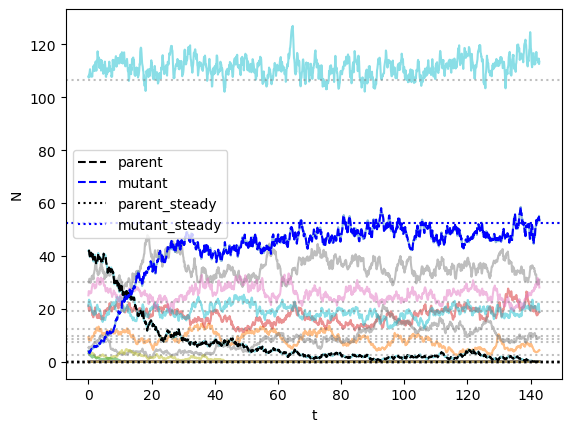

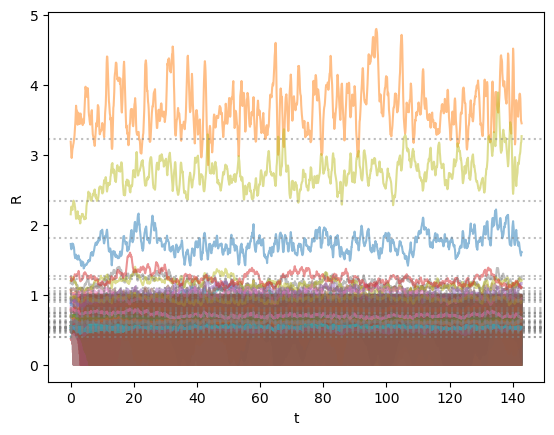

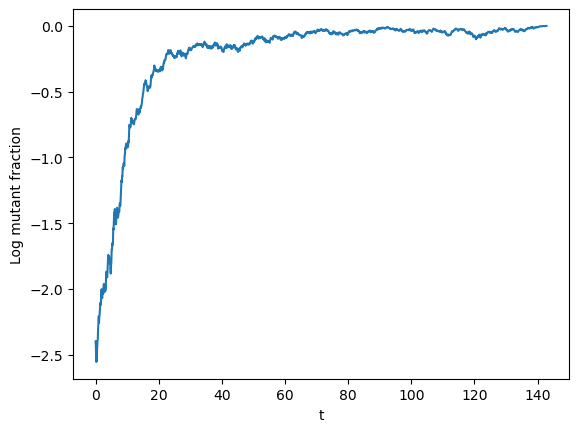

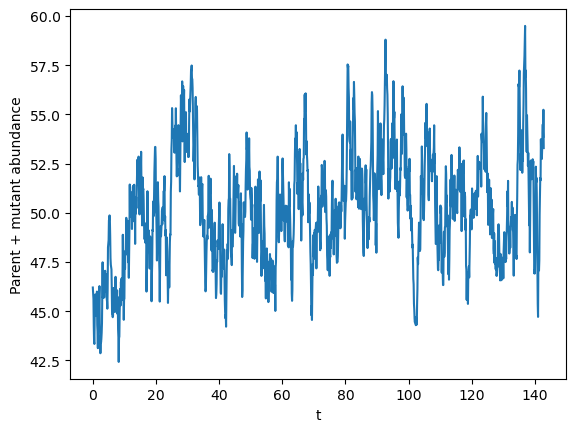

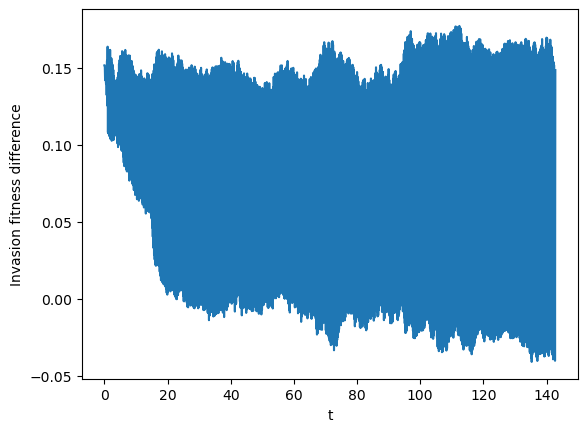

1

In [280]:
parent = 39
C_invade = mutant(parent, 0.9)
simulate(n0, r0, parent, 0, C_invade, D, 0.1, portion=0.1, plot=True)

## Fixation probability

In [95]:
# Find fixation probability using simulation trials

def fixation_probability(n0, r0, parent, delta_m, C_invade, D, temperature, trial=1000, t_final=10000, portion=0.1):
    remaining = trial
    fixation_count = 0
    while remaining > 0:
        res = simulate(n0, r0, parent, delta_m, C_invade, D, temperature, t_final, portion)
        if res > -1:
            remaining -= 1
            fixation_count += res
        else:
            print('They coexisted...🥲')
    return fixation_count / trial

In [97]:
# Fixation probability for different mutants and s

def run_trial(n0, r0, parent, s_list, temperature, rho_mutant=0.9, portion=0.1):
    C_invade = mutant(parent, rho_mutant)
    Cr = C_invade @ r0
    delta_m_list = (1 - l) * (Cr[-1] - Cr[parent]) - s_list
    probs = [fixation_probability(n0, r0, parent, delta_m, C_invade, D, temperature, portion=portion) for delta_m in tqdm(delta_m_list)]
    return probs

In [99]:
# Analytical formulas for fixation probability

# Kimura's formula
def fix_prob_theory(p, N, s):
    return (1 - np.exp(-N * s * p)) / (1 - np.exp(-N * s))

# Theory with ecology
def corrected_fix_prob_theory(p, N, a, s):
    def helper(x):
        return sp.special.erfi((a * x + s) * np.sqrt(N / 2 / a))
    return (helper(0) - helper(-p)) / (helper(0) - helper(-1))

In [320]:
# Generate data for Figure S1

parent = 39
s_range = {
    0.2: np.linspace(-0.05, 0.15, 50),
}
portion = 0.1
plot_catalog = {}
for temperature in s_range:
    plot_catalog[temperature] = Parallel(n_jobs=-2)(delayed(run_trial)(n0, r0, parent, s_range[temperature], temperature, portion=portion) for i in range(10))

results = {
    'S': S,
    'M': M,
    'mu': mu,
    'sigma': sigma,
    'K0': K0,
    'mu_m': mu_m,
    'sigma_m': sigma_m,
    'temperature': list(s_range.keys()),
    'rho_mutant': 0.9,
    'portion': portion,
    'n0': n0,
    'r0': r0,
    'C': C,
    'D': D,
    'parent': parent,
    's': s_range,
    'data': plot_catalog,
}

with open('ecopopgenfig/fixation_prob_ecrm.pkl', 'wb') as f:
    pickle.dump(results, f)

100%|██████████| 50/50 [37:26<00:00, 44.92s/it]


0.06996045111003327


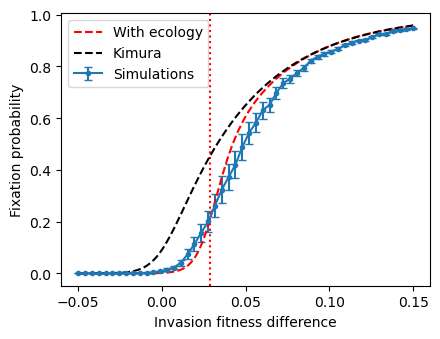

In [397]:
# Plots to compare theory and simulation

with open('ecopopgenfig/fixation_prob_ecrm.pkl', 'rb') as f:
    results = pickle.load(f)

# Calculate eta by averaging across multiple mutants
portion = results['portion']
parent = results['parent']
rho_mutant = results['rho_mutant']
Npm = results['n0'][parent] * (1 + portion)
eta_trial = []
for _ in range(1000):
    n_survivor = (results['n0'] > threshold)
    C_invade = mutant(parent, rho_mutant)
    E_invade = C_invade * r0
    C_survive = C[n_survivor, :]
    E_survive = C_survive * r0
    Qinv = np.diag(1 / (1 + C.T @ n0))
    P = Qinv @ E_survive.T @ np.linalg.inv(C_survive @ Qinv @ E_survive.T) @ C_survive
    eta_trial.append(Npm * (C_invade[-1, :] - C_invade[parent, :]) @ (np.identity(M) - P) @ Qinv @ (E_invade[-1, :] - E_invade[parent, :]))
eta = np.mean(eta_trial)

Npm = results['n0'][results['parent']] * (1 + portion)

for temperature in results['data']:
    plt.figure(figsize=(4.5,3.5))
    trials = np.array(results['data'][temperature])
    s_list = np.array(results['s'][temperature])
    s_samples = np.linspace(np.min(s_list), np.max(s_list), 150)
    mean_probs = np.nanmean(trials, axis=0)
    err_probs = np.nanstd(trials, axis=0) / np.sqrt(np.sum(~np.isnan(trials), axis=0))
    plt.errorbar(s_list, mean_probs, yerr=err_probs, fmt='o-', markersize=3, capsize=3, label='Simulations')
    
    x = np.tile(s_list, len(trials))
    y = trials.flatten()


    N_eff = Npm / temperature
    p_theory = corrected_fix_prob_theory(portion / (1 + portion), N_eff, eta, s_samples)
    plt.plot(s_samples, p_theory, c='red',linestyle='dashed', label='With ecology')
    plt.axvline(eta * (1 / 2 - portion / (1 + portion)), c='red', linestyle='dotted')
    
    p_theory = fix_prob_theory(portion / (1 + portion), N_eff, s_samples)
    plt.plot(s_samples, p_theory, c='black',linestyle='dashed', label='Kimura')
    
    plt.xlabel('Invasion fitness difference')
    plt.ylabel('Fixation probability')
    # plt.yscale('log')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()